# RetailPulse AI Retail Analytics

## Notebook 3 : Feature Engineering

### Objectives

- Create Date Features
- Create Customer Features
- Build RFM Dataset
- Save Engineered Dataset

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["Day"] = df["InvoiceDate"].dt.day

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,Day,Weekday,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,Tuesday,7


In [6]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [7]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "Invoice":"nunique",

    "TotalPrice":"sum"

})

In [8]:
rfm.columns = ["Recency","Frequency","Monetary"]

In [9]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


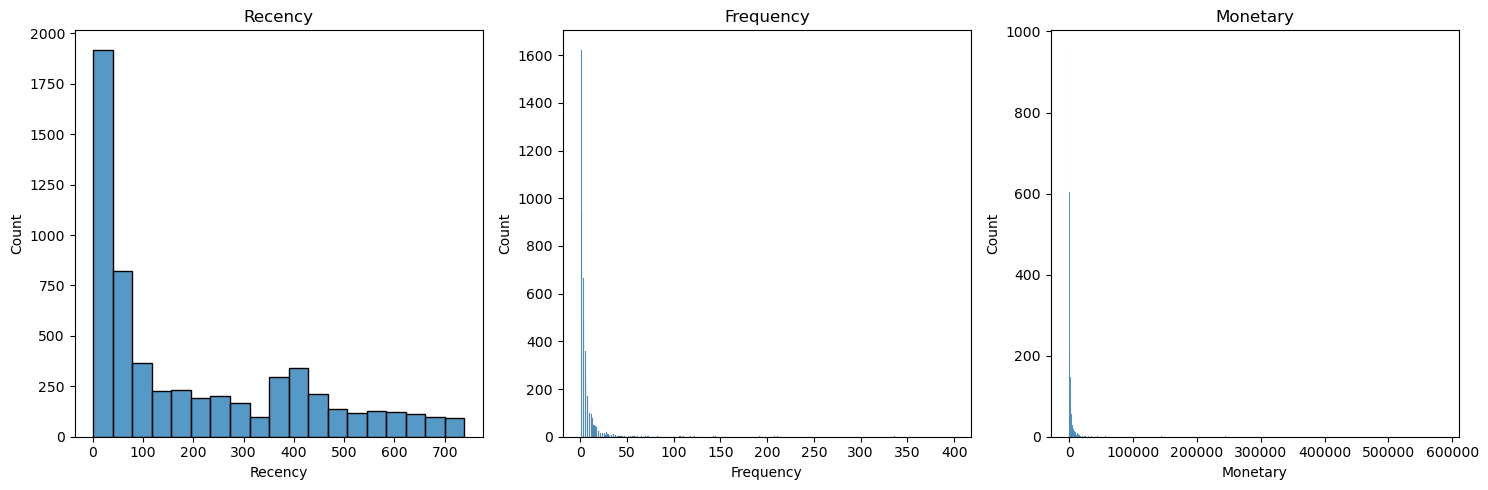

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm["Recency"])

plt.title("Recency")

plt.subplot(1,3,2)
sns.histplot(rfm["Frequency"])

plt.title("Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm["Monetary"])

plt.title("Monetary")

plt.tight_layout()

plt.show()

In [12]:
rfm.to_csv("../data/rfm_data.csv")

# Business Insights

### VIP Customers
- Highest spending customers
- Purchase very frequently
- Should receive exclusive rewards and premium membership

###  Loyal Customers
- Frequent buyers with high revenue contribution
- Target with loyalty programs and personalized offers

### Regular Customers
- Moderate purchase frequency
- Encourage repeat purchases through promotions and discounts

###  At Risk Customers
- Have not purchased for a long time
- Launch win-back campaigns with special discounts and reminder emails